In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/retail_store_inventory.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Shape: (73100, 15)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']

Data Types:
Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition         str
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality               str
dtype: object


In [5]:
missing = df.isnull().sum()

print(missing)

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Demand Forecast,0,0.0
Price,0,0.0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Number of unique dates:", df["Date"].nunique())

Start date: 2022-01-01 00:00:00
End date: 2024-01-01 00:00:00
Number of unique dates: 731


In [10]:
date_range = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

print("Expected dates:", len(date_range))
print("Actual dates:", df["Date"].nunique())

Expected dates: 731
Actual dates: 731


In [11]:
categorical_columns = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Store ID
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

Product ID
Product ID
P0001    3655
P0002    3655
P0003    3655
P0004    3655
P0005    3655
P0006    3655
P0007    3655
P0008    3655
P0009    3655
P0010    3655
P0011    3655
P0012    3655
P0013    3655
P0014    3655
P0015    3655
P0016    3655
P0017    3655
P0018    3655
P0019    3655
P0020    3655
Name: count, dtype: int64

Category
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

Region
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

Weather Condition
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

Seasonality
Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64


In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,73100,2023-01-01 00:00:00,2022-01-01 00:00:00,2022-07-02 00:00:00,2023-01-01 00:00:00,2023-07-03 00:00:00,2024-01-01 00:00:00,NaN
Inventory Level,73100.0,274.469877,50.0,162.0,273.0,387.0,500.0,129.949514
Units Sold,73100.0,136.46487,0.0,49.0,107.0,203.0,499.0,108.919406
Units Ordered,73100.0,110.004473,20.0,65.0,110.0,155.0,200.0,52.277448
Demand Forecast,73100.0,141.49472,-9.99,53.67,113.015,208.0525,518.55,109.254076
Price,73100.0,55.135108,10.0,32.65,55.05,77.86,100.0,26.021945
Discount,73100.0,10.009508,0.0,5.0,10.0,15.0,20.0,7.083746
Holiday/Promotion,73100.0,0.497305,0.0,0.0,0.0,1.0,1.0,0.499996
Competitor Pricing,73100.0,55.146077,5.03,32.68,55.01,77.82,104.94,26.191408


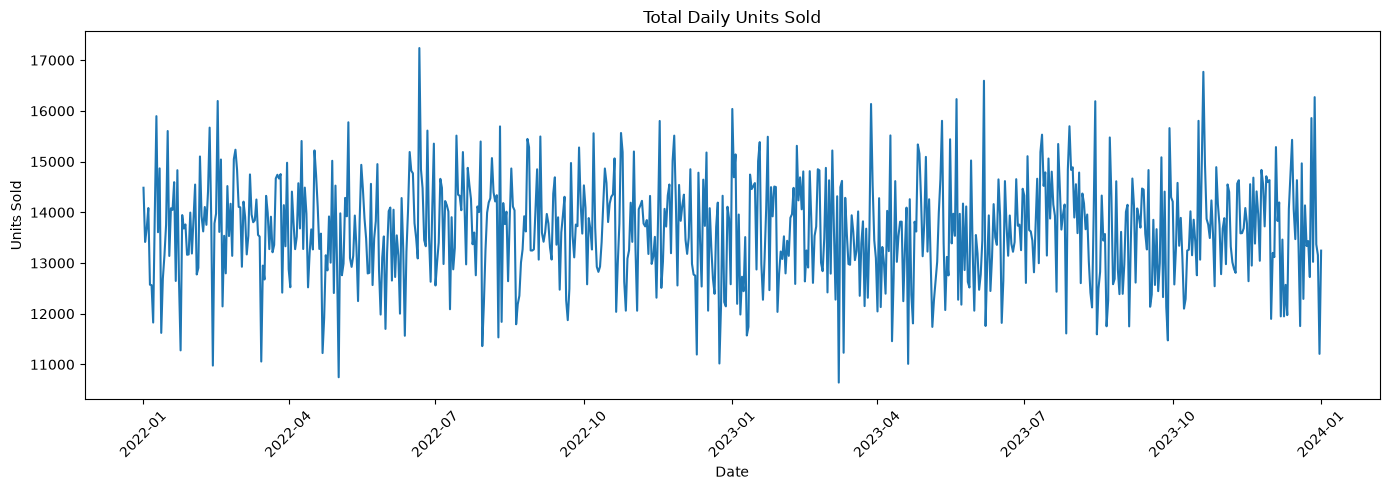

In [15]:
daily_demand = df.groupby("Date")["Units Sold"].sum()

plt.figure(figsize=(14, 5))

plt.plot(daily_demand)

plt.title("Total Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

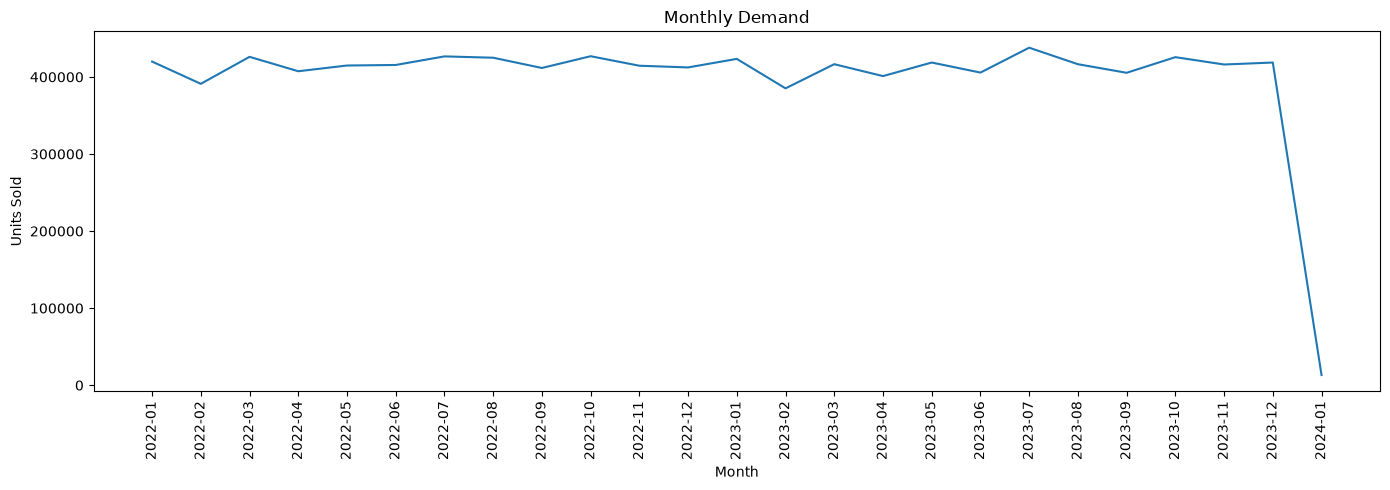

In [16]:
monthly_demand = (
    df.groupby(df["Date"].dt.to_period("M"))["Units Sold"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(monthly_demand.index.astype(str), monthly_demand.values)

plt.title("Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

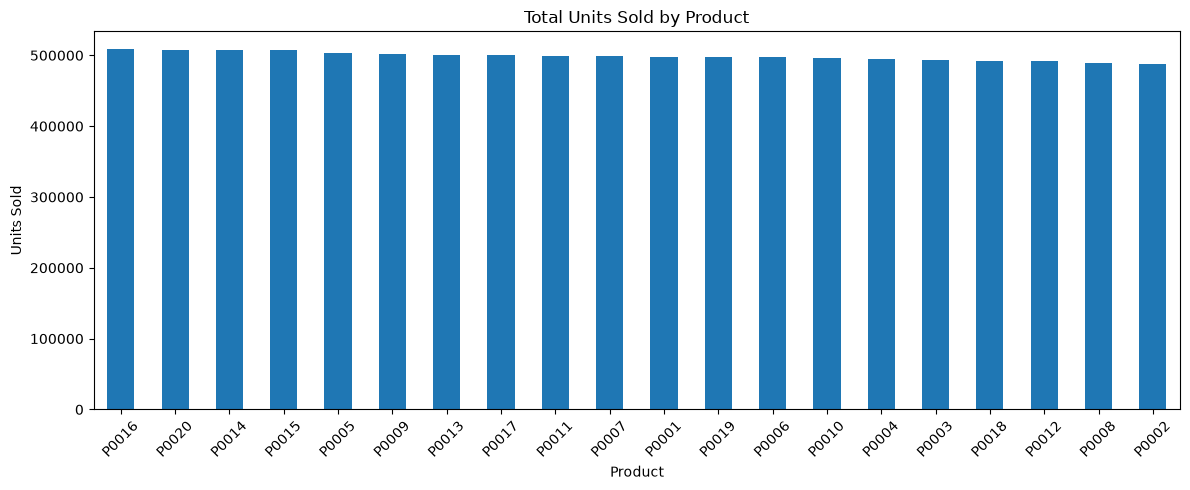

In [17]:
product_demand = (
    df.groupby("Product ID")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))

product_demand.plot(kind="bar")

plt.title("Total Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

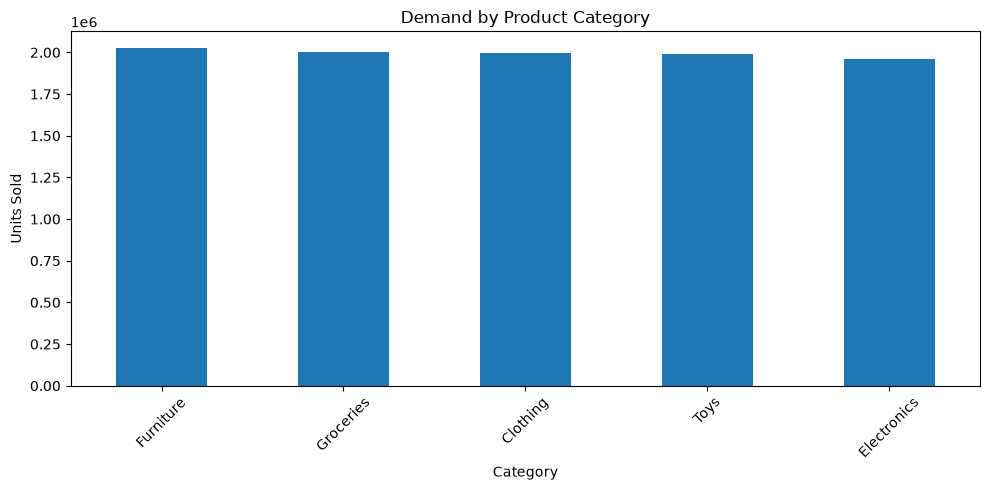

In [19]:
category_demand = (
    df.groupby("Category")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

category_demand

plt.figure(figsize=(10, 5))

category_demand.plot(kind="bar")

plt.title("Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
store_demand = (
    df.groupby("Store ID")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

store_demand

Store ID
S003    2022696
S005    2010176
S002    1987715
S004    1979245
S001    1975750
Name: Units Sold, dtype: int64

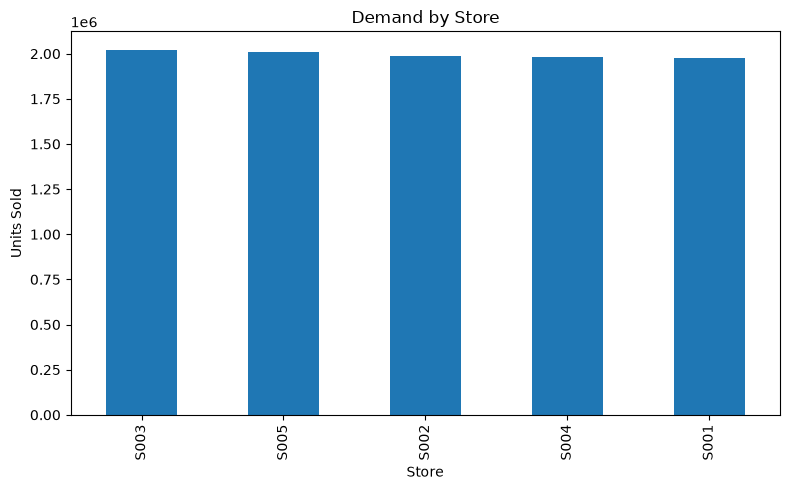

In [21]:
plt.figure(figsize=(8, 5))

store_demand.plot(kind="bar")

plt.title("Demand by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [22]:
promotion_demand = (
    df.groupby("Holiday/Promotion")["Units Sold"]
    .agg(["mean", "median", "sum", "count"])
)

promotion_demand

,mean,median,sum,count
Holiday/Promotion,,,,
0,136.505375,107.0,5016163,36747
1,136.423926,108.0,4959419,36353


In [23]:
discount_demand = (
    df.groupby("Discount")["Units Sold"]
    .mean()
)

discount_demand

Discount
0     135.694585
5     136.567405
10    136.769851
15    136.655293
20    136.640775
Name: Units Sold, dtype: float64

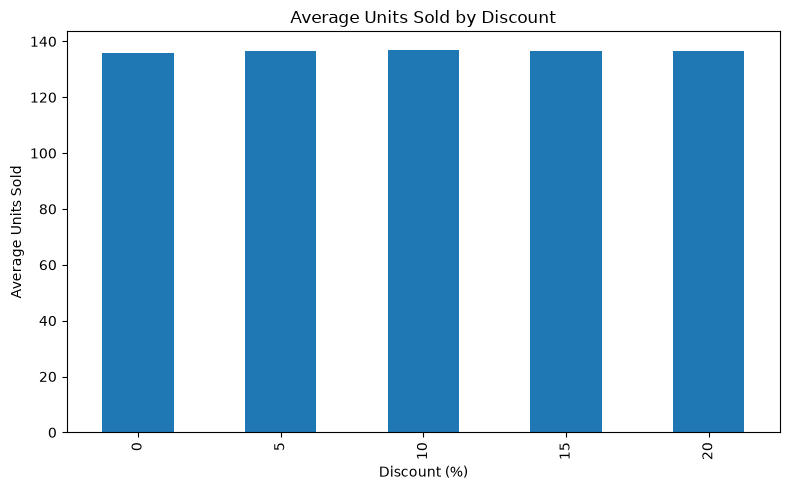

In [24]:
plt.figure(figsize=(8, 5))

discount_demand.plot(kind="bar")

plt.title("Average Units Sold by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [25]:
weather_demand = (
    df.groupby("Weather Condition")["Units Sold"]
    .agg(["mean", "median", "sum"])
)

weather_demand

,mean,median,sum
Weather Condition,,,
Cloudy,136.758324,108.0,2497207
Rainy,135.160028,107.0,2470455
Snowy,135.911559,106.0,2483376
Sunny,138.028650,109.0,2524544


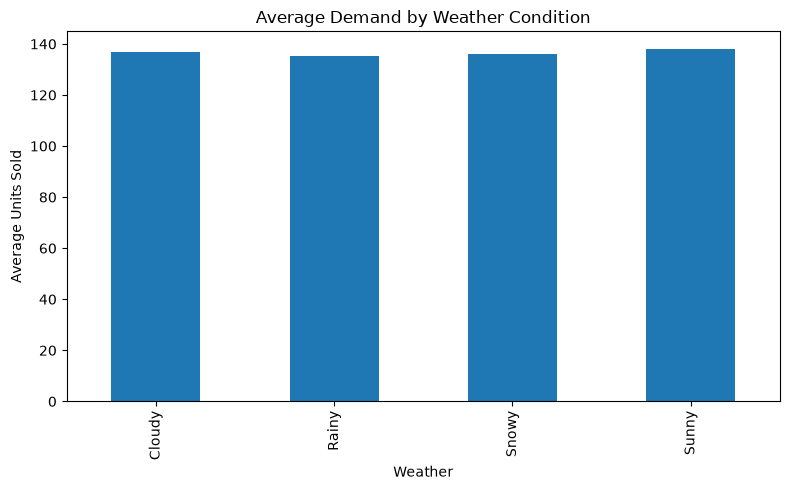

In [26]:
plt.figure(figsize=(8, 5))

weather_demand["mean"].plot(kind="bar")

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

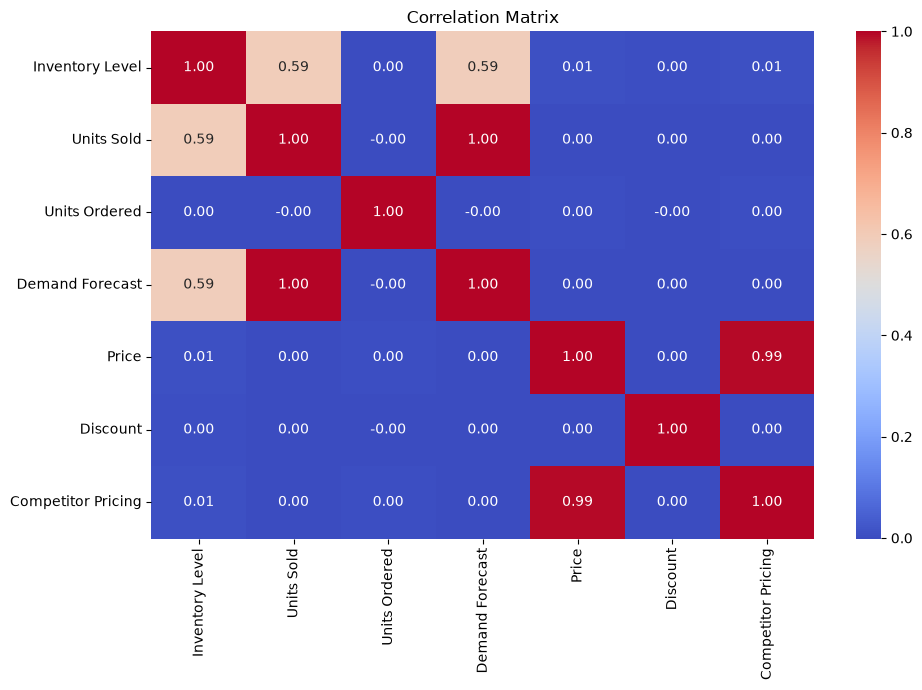

In [27]:
numerical_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]

correlation = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

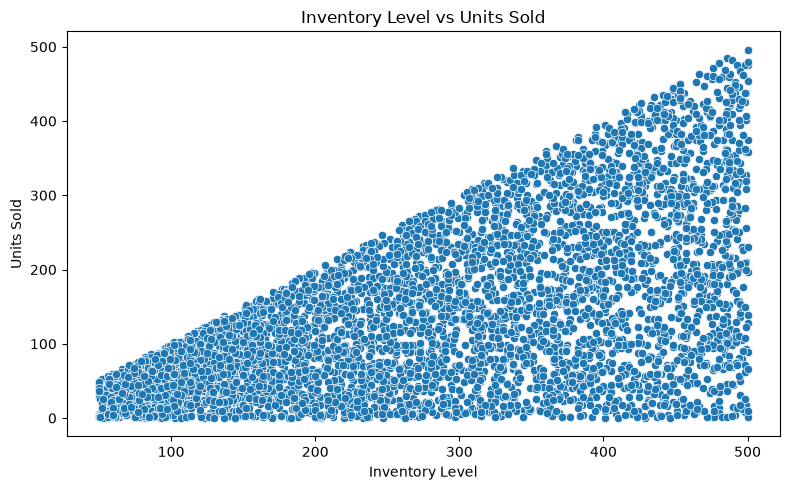

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df.sample(5000),
    x="Inventory Level",
    y="Units Sold"
)

plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [33]:
df["Day_of_Week"] = df["Date"].dt.day_name()

day_demand = (
    df.groupby("Day_of_Week")["Units Sold"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = day_demand.reindex(day_order)

day_demand

Day_of_Week
Monday       135.094667
Tuesday      137.307692
Wednesday    136.615096
Thursday     137.281923
Friday       136.851442
Saturday     135.314476
Sunday       136.809714
Name: Units Sold, dtype: float64

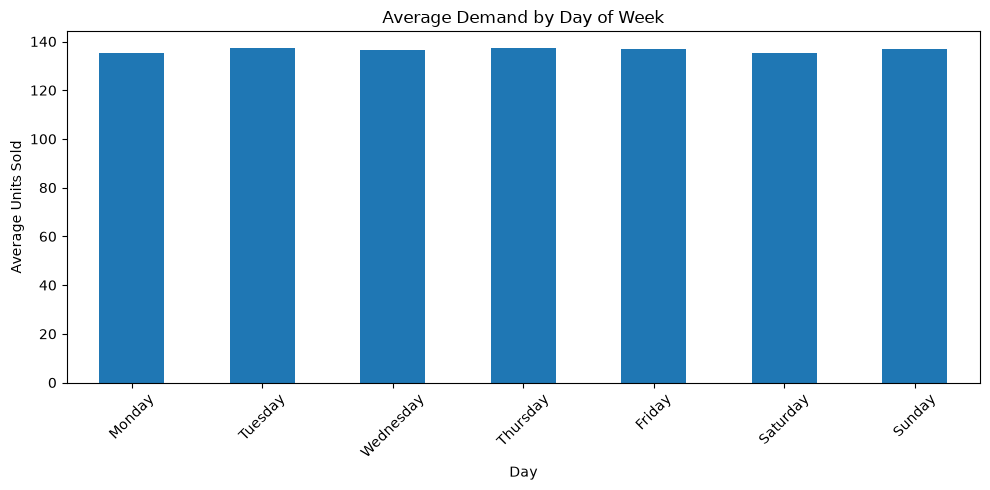

In [34]:
plt.figure(figsize=(10, 5))

day_demand.plot(kind="bar")

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
store_product_demand = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .agg(["mean", "sum", "std"])
    .reset_index()
)

store_product_demand.head(10)

,Store ID,Product ID,mean,sum,std
0,S001,P0001,137.306430,100371,108.187859
1,S001,P0002,131.038304,95789,104.313220
2,S001,P0003,141.440492,103393,107.211225
3,S001,P0004,140.904241,103001,113.644117
4,S001,P0005,133.129959,97318,107.368873
5,S001,P0006,130.673051,95522,109.015261
6,S001,P0007,137.823529,100749,111.198898
7,S001,P0008,137.132695,100244,108.699045
8,S001,P0009,131.436389,96080,107.086803
9,S001,P0010,132.361149,96756,105.916371


In [36]:
store_product_demand.sort_values(
    "mean",
    ascending=False
).head(10)

,Store ID,Product ID,mean,sum,std
94,S005,P0015,149.246238,109099,115.679314
52,S003,P0013,147.030096,107479,112.603507
20,S002,P0001,145.005472,105999,113.574271
82,S005,P0003,144.551300,105667,111.925775
44,S003,P0005,144.196990,105408,109.339960
28,S002,P0009,144.153215,105376,112.421619
39,S002,P0020,144.108071,105343,113.536540
53,S003,P0014,143.896033,105188,113.023686
75,S004,P0016,143.333789,104777,107.697996
56,S003,P0017,143.045144,104566,107.775868


In [37]:
store_product_demand.sort_values(
    "std",
    ascending=False
).head(10)

,Store ID,Product ID,mean,sum,std
94,S005,P0015,149.246238,109099,115.679314
45,S003,P0006,139.771546,102173,114.099313
3,S001,P0004,140.904241,103001,113.644117
20,S002,P0001,145.005472,105999,113.574271
39,S002,P0020,144.108071,105343,113.536540
53,S003,P0014,143.896033,105188,113.023686
29,S002,P0010,135.447332,99012,112.868931
14,S001,P0015,137.886457,100795,112.804046
26,S002,P0007,137.621067,100601,112.771693
48,S003,P0009,140.467852,102682,112.714137


# Feature Engineering

In [38]:
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

df["lag_1"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(1)
)

df["lag_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(7)
)

df["lag_14"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(14)
)

df["lag_30"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(30)
)

In [39]:
df[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Units Sold",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_30"
    ]
].head(40)

,Date,Store ID,Product ID,Units Sold,lag_1,lag_7,lag_14,lag_30
0,2022-01-01,S001,P0001,127,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,81,127.0,NaN,NaN,NaN
2,2022-01-03,S001,P0001,5,81.0,NaN,NaN,NaN
3,2022-01-04,S001,P0001,58,5.0,NaN,NaN,NaN
4,2022-01-05,S001,P0001,147,58.0,NaN,NaN,NaN
5,2022-01-06,S001,P0001,37,147.0,NaN,NaN,NaN
6,2022-01-07,S001,P0001,107,37.0,NaN,NaN,NaN
7,2022-01-08,S001,P0001,2,107.0,127.0,NaN,NaN
8,2022-01-09,S001,P0001,350,2.0,81.0,NaN,NaN
9,2022-01-10,S001,P0001,36,350.0,5.0,NaN,NaN


In [40]:
df["rolling_mean_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_30"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [41]:
df[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Units Sold",
        "rolling_mean_7",
        "rolling_mean_30"
    ]
].head(40)

,Date,Store ID,Product ID,Units Sold,rolling_mean_7,rolling_mean_30
0,2022-01-01,S001,P0001,127,NaN,NaN
1,2022-01-02,S001,P0001,81,NaN,NaN
2,2022-01-03,S001,P0001,5,NaN,NaN
3,2022-01-04,S001,P0001,58,NaN,NaN
4,2022-01-05,S001,P0001,147,NaN,NaN
5,2022-01-06,S001,P0001,37,NaN,NaN
6,2022-01-07,S001,P0001,107,NaN,NaN
7,2022-01-08,S001,P0001,2,80.285714,NaN
8,2022-01-09,S001,P0001,350,62.428571,NaN
9,2022-01-10,S001,P0001,36,100.857143,NaN


In [42]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)

In [43]:
df[
    [
        "Date",
        "Units Sold",
        "day_of_week",
        "month",
        "week_of_year"
    ]
].head(15)

,Date,Units Sold,day_of_week,month,week_of_year
0,2022-01-01,127,5,1,52
1,2022-01-02,81,6,1,52
2,2022-01-03,5,0,1,1
3,2022-01-04,58,1,1,1
4,2022-01-05,147,2,1,1
5,2022-01-06,37,3,1,1
6,2022-01-07,107,4,1,1
7,2022-01-08,2,5,1,1
8,2022-01-09,350,6,1,1
9,2022-01-10,36,0,1,2


In [44]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30"
]

df[feature_cols].isna().sum()

lag_1               100
lag_7               700
lag_14             1400
lag_30             3000
rolling_mean_7      700
rolling_mean_30    3000
dtype: int64

In [45]:
df_model = df.dropna(subset=feature_cols).copy()

In [46]:
print("Original rows:", len(df))
print("Modeling rows:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 73100
Modeling rows: 70100
Rows removed: 3000


In [47]:
X = df_model[
    [
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_30",
        "day_of_week",
        "month",
        "week_of_year"
    ]
]

y = df_model["Units Sold"]

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70100, 9)
y shape: (70100,)


In [49]:
print("Start date:", df_model["Date"].min())
print("End date:", df_model["Date"].max())

Start date: 2022-01-31 00:00:00
End date: 2024-01-01 00:00:00


In [50]:
split_date = df_model["Date"].quantile(0.80)

print("Split date:", split_date)

Split date: 2023-08-14 00:00:00


In [51]:
train = df_model[df_model["Date"] < split_date].copy()
test = df_model[df_model["Date"] >= split_date].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))
print("Training period:", train["Date"].min(), "to", train["Date"].max())
print("Testing period:", test["Date"].min(), "to", test["Date"].max())

Training rows: 56000
Testing rows: 14100
Training period: 2022-01-31 00:00:00 to 2023-08-13 00:00:00
Testing period: 2023-08-14 00:00:00 to 2024-01-01 00:00:00


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_pred = test["rolling_mean_7"]

baseline_mae = mean_absolute_error(
    test["Units Sold"],
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["Units Sold"],
        baseline_pred
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 93.21936170212766
Baseline RMSE: 115.46352486343525


In [56]:
df_model.to_csv(
    "../data/processed/smartstock_features.csv",
    index=False
)